In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Churn_Modelling.xlsx")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1.0,15634602.0,Hargrave,619.0,France,Female,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,2.0,15647311.0,Hill,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,3.0,15619304.0,Onio,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,4.0,15701354.0,Boni,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,5.0,15737888.0,Mitchell,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  float64
 1   CustomerId       10000 non-null  float64
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  float64
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  float64
 7   Tenure           10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  float64
 10  HasCrCard        10000 non-null  float64
 11  IsActiveMember   10000 non-null  float64
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  float64
dtypes: float64(11), object(3)
memory usage: 1.1+ MB


In [5]:
#checking the percentage unique
for col in data.columns :
    print(" col_name : " , col , " unique percentage : " , len(data[col].unique())/len(data))

 col_name :  RowNumber  unique percentage :  1.0
 col_name :  CustomerId  unique percentage :  1.0
 col_name :  Surname  unique percentage :  0.2932
 col_name :  CreditScore  unique percentage :  0.046
 col_name :  Geography  unique percentage :  0.0003
 col_name :  Gender  unique percentage :  0.0002
 col_name :  Age  unique percentage :  0.007
 col_name :  Tenure  unique percentage :  0.0011
 col_name :  Balance  unique percentage :  0.6382
 col_name :  NumOfProducts  unique percentage :  0.0004
 col_name :  HasCrCard  unique percentage :  0.0002
 col_name :  IsActiveMember  unique percentage :  0.0002
 col_name :  EstimatedSalary  unique percentage :  0.9999
 col_name :  Exited  unique percentage :  0.0002


In [6]:
#deleting RowNumber , CustomerId and Surname
data = data.drop(["RowNumber" , "CustomerId" , "Surname"] , axis = 1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619.0,France,Female,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0


In [7]:
#label encode the object datatypes
from sklearn.preprocessing import LabelEncoder
d_types = dict(data.dtypes)
for name , type_ in d_types.items():
    if str(type_) == 'object':
        Le = LabelEncoder()
        data[name] = Le.fit_transform(data[name])

In [8]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619.0,0,0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,608.0,2,0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,502.0,0,0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,699.0,0,0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,850.0,2,0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0


In [9]:
remaining_columns = list(data.columns)
remaining_columns.remove("Exited")

In [10]:
X = data[remaining_columns].values
Y = data['Exited'].values.astype(np.uint8)

In [11]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size = 0.2, random_state=0)

In [12]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

Xtrain = Scaler.fit_transform(Xtrain)
Xtest = Scaler.transform(Xtest)


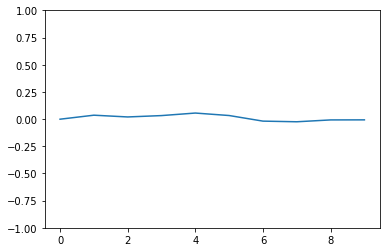

In [13]:
#check whether the data is standardized or not
#the mean should be 1
plt.ylim(-1,1)
means = []
for i in range(X.shape[1]):
    means.append(np.mean(Xtest[:, i]))
plt.plot(means, scaley=False)    

Applying Grid Search

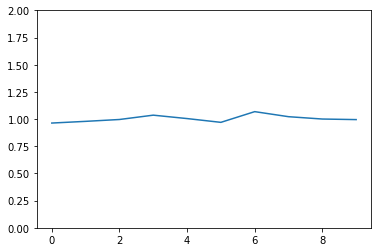

In [14]:
#check the variances
plt.ylim(0,2)
vars = []
for i in range(X.shape[1]):
    vars.append(np.var(Xtest[:, i]))
plt.plot(vars)

In [16]:
#applying Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
model = LogisticRegression()
model.fit(Xtrain, Ytrain)
model.score(Xtest, Ytest)

0.807

In [25]:
param_grid = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
              'C': [1.0, 2.0, 3.0],
              'max_iter': [100, 200, 300, 500],
              'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']}
model = LogisticRegression()
grid_search = GridSearchCV(model, param_grid)
grid_search.fit(Xtrain, Ytrain)

C:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1483: UserWarning: Setting penalty='none' will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1483: UserWarning: Setting penalty='none' will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1483: UserWarning: Setting penalty='none' will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1483: UserWarning: Setting penalty='none' will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1483: UserWarning: Setting penalty='none' will ignore the C a

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [1.0, 2.0, 3.0], 'max_iter': [100, 200, 300, 500],
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']})

In [31]:
grid_search.best_params_

{'C': 1.0, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}

In [32]:
grid_search.score(Xtest, Ytest)

0.807

Coeficients and Intercepts


In [33]:
model.coef_

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [34]:
model.intercept_

AttributeError: 'LogisticRegression' object has no attribute 'intercept_'

In [30]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [ ]:
sigmoid(model.coef_.dot(Xtest[10,:]) + model.intercept_)

array([0.12578988])

In [ ]:
np.round(sigmoid(model.coef_.dot(Xtest[10,:]) + model.intercept_))

array([0.])

In [ ]:
model.predict(Xtest[10,:].reshape(1,-1))

array([0], dtype=uint8)